In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class Generatorf1(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 2),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.network(z)

class Generatorf2(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),
            
            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.network(z)


class Generatorf3(nn.Module):
    def __init__(self, num_feature=8):
        super().__init__()

        self.num_feature = num_feature

        self.network = nn.Sequential(
            nn.Linear(num_feature * 2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 2)
        )

    def forward(self, y):

        features = []

        for n in range(1, self.num_feature + 1):
            features.append(torch.sin(2 * torch.pi * n * y))
            features.append(torch.cos(2 * torch.pi * n * y))

        features = torch.cat(features, dim=1)

        return self.network(features)

def gaussian_kernel(x, y, sigma=1.0):
    distances = torch.cdist(x, y) ** 2
    return torch.exp(-distances / (2 * sigma ** 2))


def mmd_loss(x, y, sigma=0.1):

    k_xx = gaussian_kernel(x, x, sigma)
    k_yy = gaussian_kernel(y, y, sigma)
    k_xy = gaussian_kernel(x, y, sigma)

    loss = (
        k_xx.mean()
        + k_yy.mean()
        - 2 * k_xy.mean()
    )

    return loss

In [2]:

torch.manual_seed(42)
f1 = Generatorf1()

learning_rate = 0.01
num_iterations = 5000
batch_size = 256

loss_history_f1 = []


for iteration in range(num_iterations):

    # Generate a minibatch from N(0, I)
    z = torch.randn(batch_size, 2)

    # Generate empirical samples from U([0, 1]^2)
    target = torch.rand(batch_size, 2)

    # Forward pass
    generated = f1(z)

    # Compare generated and target distributions
    loss = mmd_loss(generated, target)

    # Remove gradients from the previous iteration
    f1.zero_grad()

    # Calculate gradients using backpropagation
    loss.backward()

    # Explicit SGD update:
    # parameter_new = parameter_old - learning_rate * gradient
    with torch.no_grad():
        for parameter in f1.parameters():
            parameter -= learning_rate * parameter.grad

    # Store the loss
    loss_history_f1.append(loss.item())

    if iteration % 500 == 0:
        print(
            f"Iteration {iteration:4d} | "
            f"Loss: {loss.item():.6f}"
        )

    # Clear gradients before the next iteration
    f1.zero_grad()

Iteration    0 | Loss: 0.851574
Iteration  500 | Loss: 0.018830
Iteration 1000 | Loss: 0.014357
Iteration 1500 | Loss: 0.012903
Iteration 2000 | Loss: 0.008467
Iteration 2500 | Loss: 0.007944
Iteration 3000 | Loss: 0.011322
Iteration 3500 | Loss: 0.009625
Iteration 4000 | Loss: 0.007496
Iteration 4500 | Loss: 0.005059


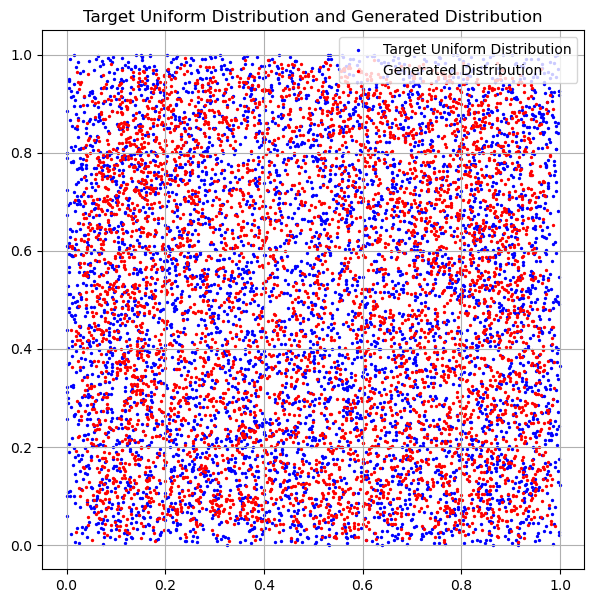

In [3]:
with torch.no_grad():
    z_test = torch.randn(5000, 2)
    generated_test = f1(z_test)

    target_test = torch.rand(5000, 2)

plt.figure(figsize=(7, 7))

plt.scatter(
    target_test[:, 0],
    target_test[:, 1],
    s=2,
    color="blue",
    label="Target Uniform Distribution"
)

plt.scatter(
    generated_test[:, 0],
    generated_test[:, 1],
    s=2,
    color="red",
    label="Generated Distribution"
)

plt.title("Target Uniform Distribution and Generated Distribution")
plt.grid()
plt.savefig("targetVSgenf1")
plt.legend(loc="upper right")
plt.show()

In [4]:

torch.manual_seed(42)
f2 = Generatorf2()

learning_rate = 0.01
num_iterations = 10000
batch_size = 512

loss_history = []


for iteration in range(num_iterations):

    # Generate a minibatch from N(0, I)
    target = torch.randn(batch_size, 2)

    # Generate empirical samples from U([0, 1]^2)
    z = torch.rand(batch_size, 2)

    # Forward pass
    generated = f2(z)

    # Compare generated and target distributions
    loss = mmd_loss(generated, target)

    # Remove gradients from the previous iteration
    f2.zero_grad()

    # Calculate gradients using backpropagation
    loss.backward()

    # Explicit SGD update:
    # parameter_new = parameter_old - learning_rate * gradient
    with torch.no_grad():
        for parameter in f2.parameters():
            parameter -= learning_rate * parameter.grad

    # Store the loss
    loss_history.append(loss.item())

    if iteration % 500 == 0:
        print(
            f"Iteration {iteration:4d} | "
            f"Loss: {loss.item():.6f}"
        )

    # Clear gradients before the next iteration
    f2.zero_grad()

Iteration    0 | Loss: 0.931694
Iteration  500 | Loss: 0.014972
Iteration 1000 | Loss: 0.008927
Iteration 1500 | Loss: 0.006406
Iteration 2000 | Loss: 0.006536
Iteration 2500 | Loss: 0.006323
Iteration 3000 | Loss: 0.006473
Iteration 3500 | Loss: 0.005179
Iteration 4000 | Loss: 0.005262
Iteration 4500 | Loss: 0.006429
Iteration 5000 | Loss: 0.004670
Iteration 5500 | Loss: 0.004746
Iteration 6000 | Loss: 0.005902
Iteration 6500 | Loss: 0.005202
Iteration 7000 | Loss: 0.005982
Iteration 7500 | Loss: 0.005217
Iteration 8000 | Loss: 0.004613
Iteration 8500 | Loss: 0.004896
Iteration 9000 | Loss: 0.005395
Iteration 9500 | Loss: 0.005185


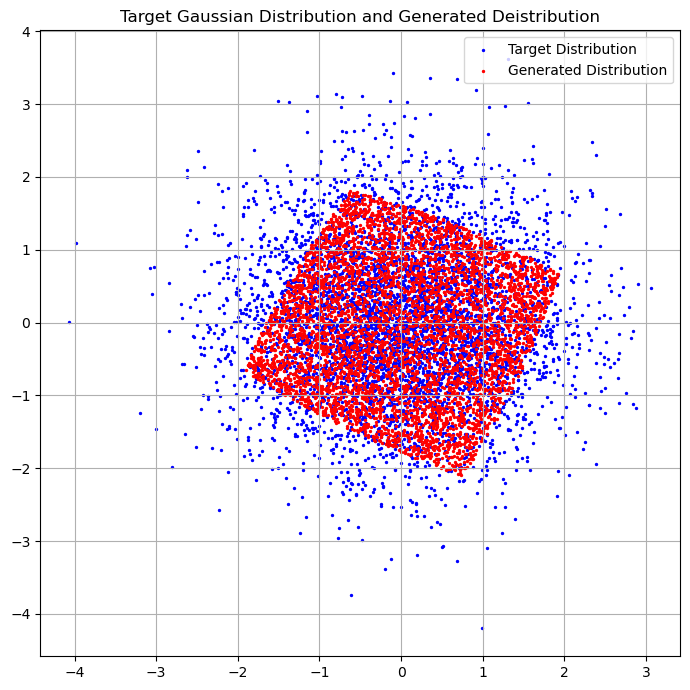

In [5]:
with torch.no_grad():
    z_test = torch.rand(5000, 2)
    generated_test = f2(z_test)
    target_test = torch.randn(5000, 2)



plt.figure(figsize=(7, 7))

plt.scatter(
    target_test[:, 0],
    target_test[:, 1],
    s=2,
    color="blue",
    label="Target Distribution"
)
plt.scatter(
    generated_test[:, 0],
    generated_test[:, 1],
    s=2,
    color="red",
    label="Generated Distribution"
)

plt.title("Target Gaussian Distribution and Generated Deistribution")
plt.grid()

plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("targetVSgenf2")
plt.show()

In [6]:
def l1_penalty(model):
    return sum(
        torch.abs(parameter).sum()
        for name, parameter in model.named_parameters()
        if "weight" in name
    )


def l2_penalty(model):
    return sum(
        (parameter ** 2).sum()
        for name, parameter in model.named_parameters()
        if "weight" in name
    )

Iteration    0 | MMD Loss: 0.851574 | Total Loss: 1.161731
Iteration  500 | MMD Loss: 0.021113 | Total Loss: 0.322694
Iteration 1000 | MMD Loss: 0.015569 | Total Loss: 0.299239
Iteration 1500 | MMD Loss: 0.013892 | Total Loss: 0.279443
Iteration 2000 | MMD Loss: 0.010588 | Total Loss: 0.258656
Iteration 2500 | MMD Loss: 0.007910 | Total Loss: 0.239306
Iteration 3000 | MMD Loss: 0.012229 | Total Loss: 0.227808
Iteration 3500 | MMD Loss: 0.011914 | Total Loss: 0.212631
Iteration 4000 | MMD Loss: 0.008868 | Total Loss: 0.195539
Iteration 4500 | MMD Loss: 0.005815 | Total Loss: 0.179345


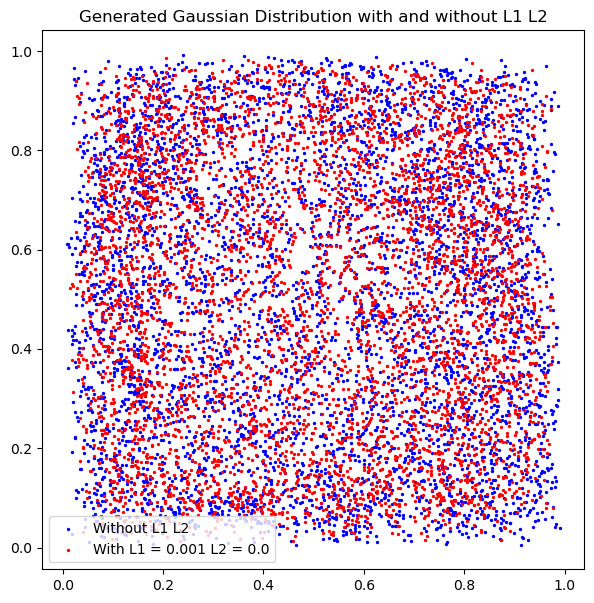

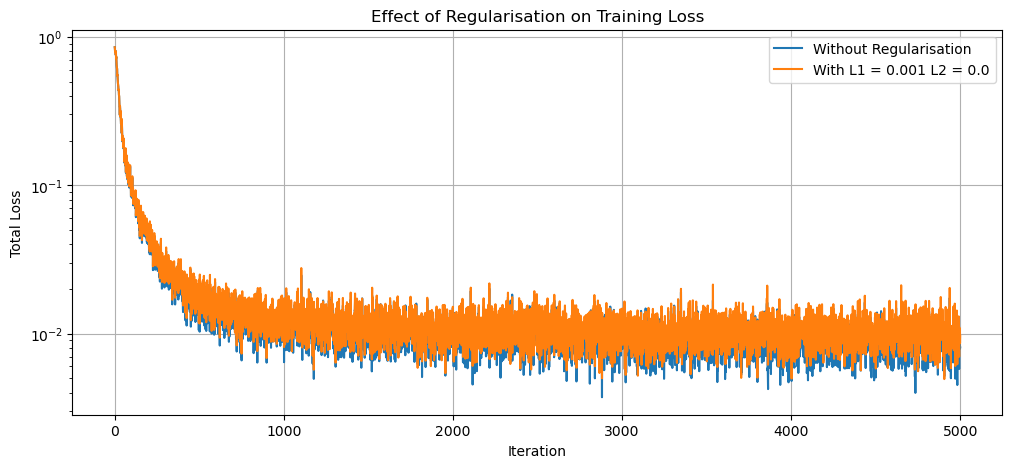

Iteration    0 | MMD Loss: 0.851574 | Total Loss: 2.402355
Iteration  500 | MMD Loss: 0.034854 | Total Loss: 1.168467
Iteration 1000 | MMD Loss: 0.027618 | Total Loss: 0.807893
Iteration 1500 | MMD Loss: 0.026815 | Total Loss: 0.559922
Iteration 2000 | MMD Loss: 0.030626 | Total Loss: 0.416978
Iteration 2500 | MMD Loss: 0.019781 | Total Loss: 0.341372
Iteration 3000 | MMD Loss: 0.024675 | Total Loss: 0.319636
Iteration 3500 | MMD Loss: 0.024416 | Total Loss: 0.298908
Iteration 4000 | MMD Loss: 0.019208 | Total Loss: 0.276707
Iteration 4500 | MMD Loss: 0.014184 | Total Loss: 0.256513


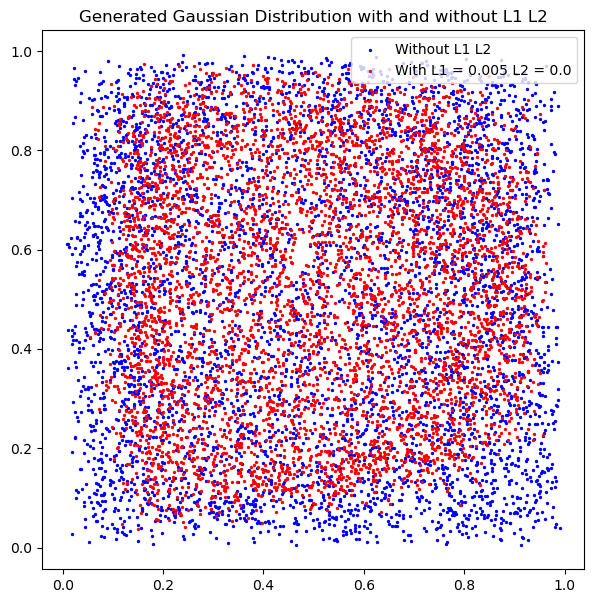

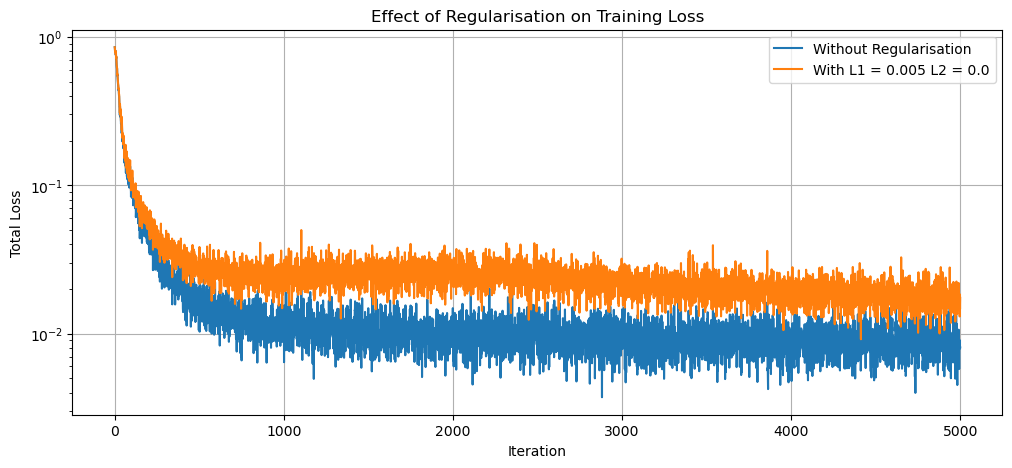

Iteration    0 | MMD Loss: 0.851574 | Total Loss: 3.953136
Iteration  500 | MMD Loss: 0.062003 | Total Loss: 1.588767
Iteration 1000 | MMD Loss: 0.054072 | Total Loss: 0.787704
Iteration 1500 | MMD Loss: 0.043058 | Total Loss: 0.596994
Iteration 2000 | MMD Loss: 0.044092 | Total Loss: 0.528293
Iteration 2500 | MMD Loss: 0.027637 | Total Loss: 0.455888
Iteration 3000 | MMD Loss: 0.032837 | Total Loss: 0.414690
Iteration 3500 | MMD Loss: 0.030624 | Total Loss: 0.371516
Iteration 4000 | MMD Loss: 0.024135 | Total Loss: 0.329062
Iteration 4500 | MMD Loss: 0.019407 | Total Loss: 0.293032


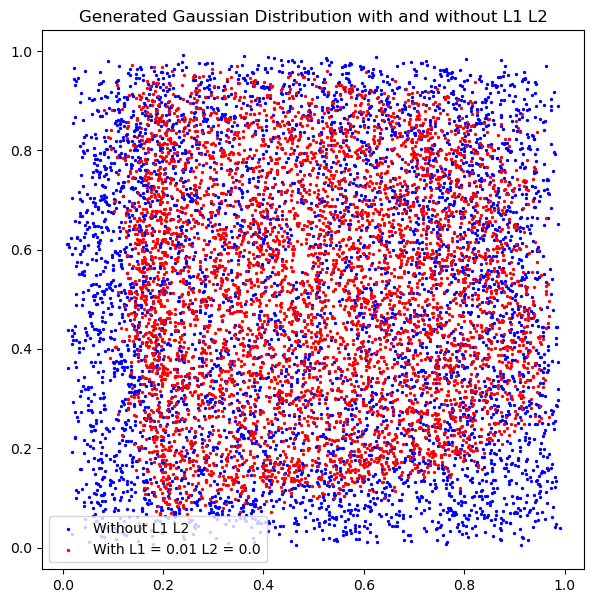

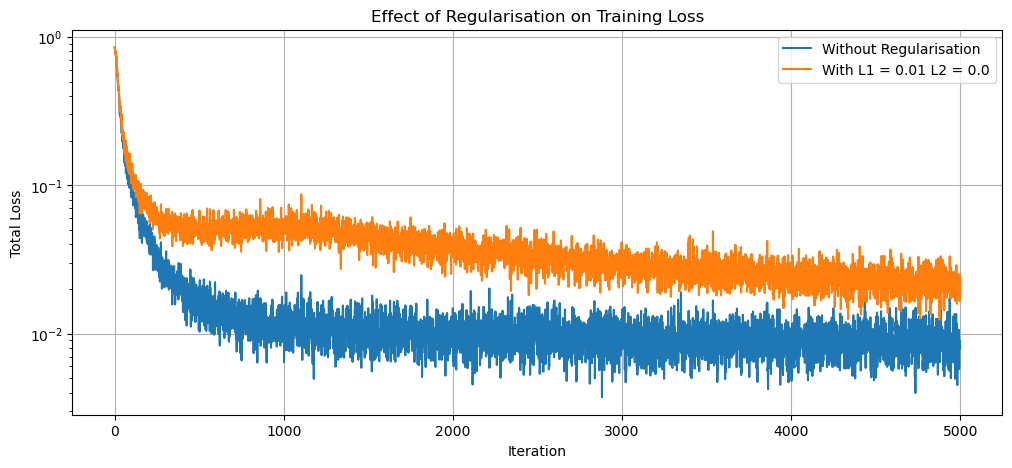

In [7]:
lambda_l2 = 0.0
for lambda_l1 in [0.001, 0.005, 0.01]:
    torch.manual_seed(42)
    f1L1L2 = Generatorf1()
    loss_history = []
    mmd_history = []
    learning_rate = 0.01
    num_iterations = 5000
    batch_size = 256

    for iteration in range(num_iterations):
    
        # Generate a minibatch from N(0, I)
        z = torch.randn(batch_size, 2)
    
        # Generate empirical samples from U([0, 1]^2)
        target = torch.rand(batch_size, 2)
    
        # Forward pass
        generated = f1L1L2(z)
    
        # Compare generated and target distributions
        mmd = mmd_loss(generated, target)
        
        l1 = l1_penalty(f1L1L2)
        l2 = l2_penalty(f1L1L2)
        
        loss = mmd + lambda_l1 * l1 + lambda_l2 * l2
    
        # Remove gradients from the previous iteration
        f1L1L2.zero_grad()
    
        # Calculate gradients using backpropagation
        loss.backward()
    
        # Explicit SGD update:
        # parameter_new = parameter_old - learning_rate * gradient
        with torch.no_grad():
            for parameter in f1L1L2.parameters():
                parameter -= learning_rate * parameter.grad
    
        # Store the loss
        loss_history.append(loss.item())
        mmd_history.append(mmd.item())
    
    
        if iteration % 500 == 0:
            print(
                f"Iteration {iteration:4d} | "
                f"MMD Loss: {mmd.item():.6f} | "
                f"Total Loss: {loss.item():.6f}"
            )
    with torch.no_grad():
        z_test = torch.randn(5000, 2)
        generated_test = f1(z_test)
        generated_test_withL1L2 = f1L1L2(z_test)
    
    plt.figure(figsize=(7, 7))
    
    plt.scatter(
        generated_test[:, 0],
        generated_test[:, 1],
        s=2,
        color="blue",
        label="Without L1 L2"
    )
    plt.scatter(
        generated_test_withL1L2[:, 0],
        generated_test_withL1L2[:, 1],
        s=2,
        color="red",
        label="With L1 = " + str(lambda_l1) +
              " L2 = " + str(lambda_l2)
    )
    
    plt.title("Generated Gaussian Distribution with and without L1 L2")
    plt.legend()        
    plt.savefig(
        "genf1L1" + str(lambda_l1) +
        "L2" + str(lambda_l2) + ".png",
        bbox_inches="tight"
    )
    plt.show()
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(loss_history_f1, label="Without Regularisation")
    plt.plot(mmd_history, label="With L1 = " + str(lambda_l1) +" L2 = " + str(lambda_l2))
    
    plt.xlabel("Iteration")
    plt.ylabel("Total Loss")
    plt.title("Effect of Regularisation on Training Loss")
    plt.legend()
    plt.grid()
    plt.yscale("log")
    plt.savefig(
        "lossgenf1L1" + str(lambda_l1) +
        "L2" + str(lambda_l2) + ".png",
        bbox_inches="tight"
    )
    plt.show()


Iteration    0 | MMD Loss: 0.851574 | Total Loss: 0.895360
Iteration  500 | MMD Loss: 0.019502 | Total Loss: 0.065909
Iteration 1000 | MMD Loss: 0.014666 | Total Loss: 0.060821
Iteration 1500 | MMD Loss: 0.013125 | Total Loss: 0.058677
Iteration 2000 | MMD Loss: 0.009091 | Total Loss: 0.053960
Iteration 2500 | MMD Loss: 0.007864 | Total Loss: 0.052026
Iteration 3000 | MMD Loss: 0.011316 | Total Loss: 0.054772
Iteration 3500 | MMD Loss: 0.010216 | Total Loss: 0.052987
Iteration 4000 | MMD Loss: 0.007584 | Total Loss: 0.049677
Iteration 4500 | MMD Loss: 0.005074 | Total Loss: 0.046513


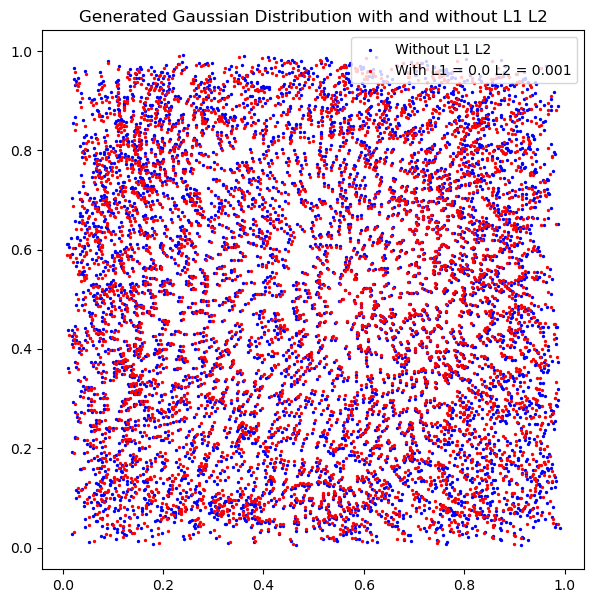

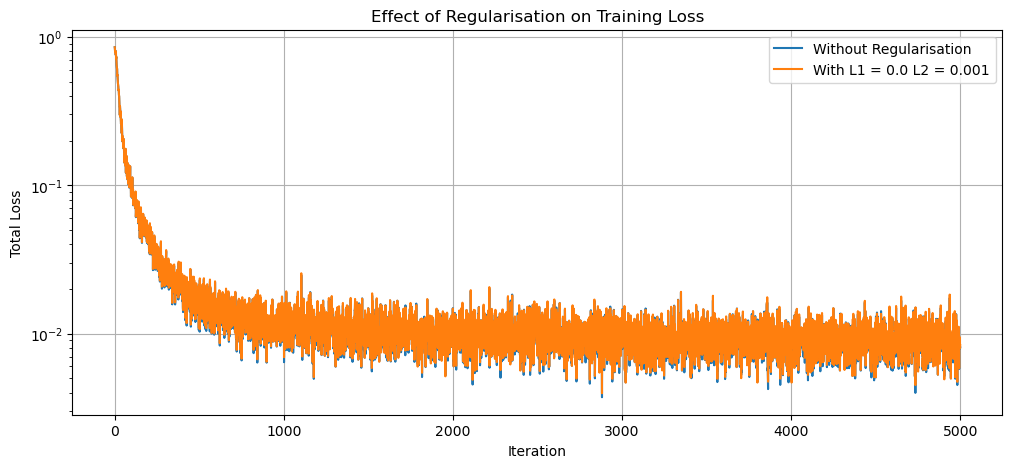

Iteration    0 | MMD Loss: 0.851574 | Total Loss: 1.070503
Iteration  500 | MMD Loss: 0.022476 | Total Loss: 0.237902
Iteration 1000 | MMD Loss: 0.016450 | Total Loss: 0.216247
Iteration 1500 | MMD Loss: 0.014718 | Total Loss: 0.199104
Iteration 2000 | MMD Loss: 0.012423 | Total Loss: 0.182670
Iteration 2500 | MMD Loss: 0.008757 | Total Loss: 0.166162
Iteration 3000 | MMD Loss: 0.012646 | Total Loss: 0.158441
Iteration 3500 | MMD Loss: 0.013394 | Total Loss: 0.148780
Iteration 4000 | MMD Loss: 0.009082 | Total Loss: 0.135061
Iteration 4500 | MMD Loss: 0.006555 | Total Loss: 0.124112


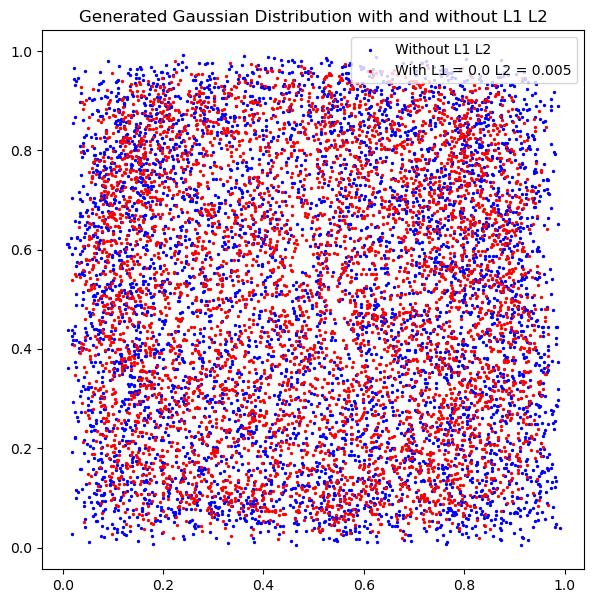

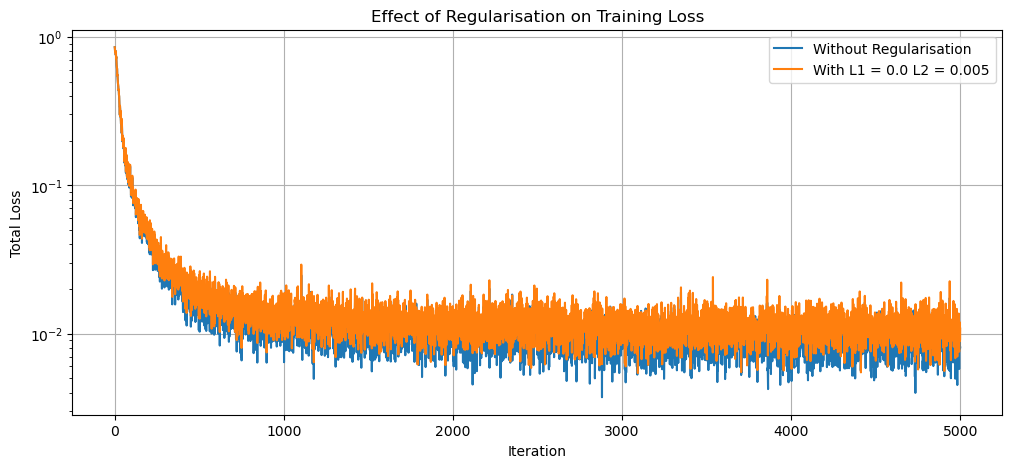

Iteration    0 | MMD Loss: 0.851574 | Total Loss: 1.289431
Iteration  500 | MMD Loss: 0.026794 | Total Loss: 0.419716
Iteration 1000 | MMD Loss: 0.019779 | Total Loss: 0.354749
Iteration 1500 | MMD Loss: 0.017943 | Total Loss: 0.304044
Iteration 2000 | MMD Loss: 0.018185 | Total Loss: 0.264471
Iteration 2500 | MMD Loss: 0.012272 | Total Loss: 0.226179
Iteration 3000 | MMD Loss: 0.016524 | Total Loss: 0.204171
Iteration 3500 | MMD Loss: 0.018552 | Total Loss: 0.185071
Iteration 4000 | MMD Loss: 0.013174 | Total Loss: 0.162566
Iteration 4500 | MMD Loss: 0.011352 | Total Loss: 0.146963


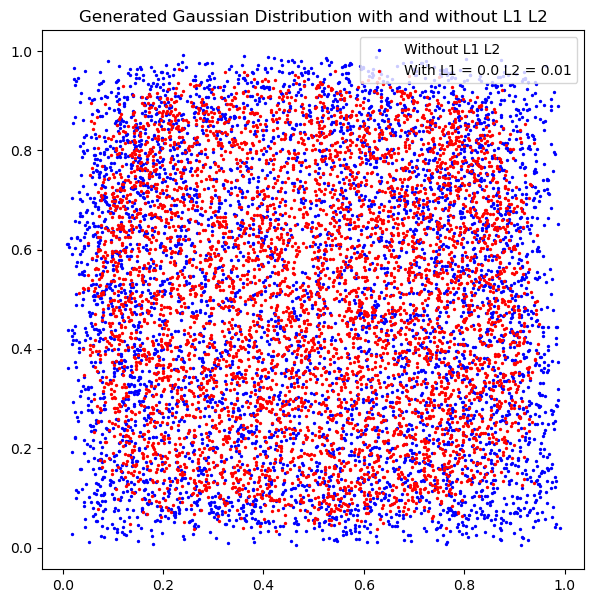

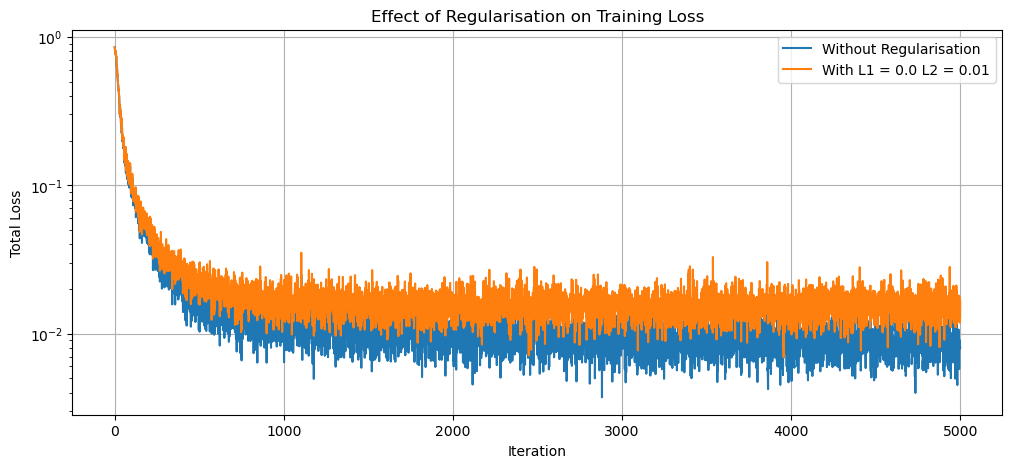

In [8]:
lambda_l1 = 0.0
for lambda_l2 in [0.001, 0.005, 0.01]:
    torch.manual_seed(42)
    f1L1L2 = Generatorf1()
    loss_history = []
    mmd_history = []
    learning_rate = 0.01
    num_iterations = 5000
    batch_size = 256

    for iteration in range(num_iterations):
    
        # Generate a minibatch from N(0, I)
        z = torch.randn(batch_size, 2)
    
        # Generate empirical samples from U([0, 1]^2)
        target = torch.rand(batch_size, 2)
    
        # Forward pass
        generated = f1L1L2(z)
    
        # Compare generated and target distributions
        mmd = mmd_loss(generated, target)
        
        l1 = l1_penalty(f1L1L2)
        l2 = l2_penalty(f1L1L2)
        
        loss = mmd + lambda_l1 * l1 + lambda_l2 * l2
    
        # Remove gradients from the previous iteration
        f1L1L2.zero_grad()
    
        # Calculate gradients using backpropagation
        loss.backward()
    
        # Explicit SGD update:
        # parameter_new = parameter_old - learning_rate * gradient
        with torch.no_grad():
            for parameter in f1L1L2.parameters():
                parameter -= learning_rate * parameter.grad
    
        # Store the loss
        loss_history.append(loss.item())
        mmd_history.append(mmd.item())
    
    
        if iteration % 500 == 0:
            print(
                f"Iteration {iteration:4d} | "
                f"MMD Loss: {mmd.item():.6f} | "
                f"Total Loss: {loss.item():.6f}"
            )
    with torch.no_grad():
        z_test = torch.randn(5000, 2)
        generated_test = f1(z_test)
        generated_test_withL1L2 = f1L1L2(z_test)
    
    plt.figure(figsize=(7, 7))
    
    plt.scatter(
        generated_test[:, 0],
        generated_test[:, 1],
        s=2,
        color="blue",
        label="Without L1 L2"
    )
    plt.scatter(
        generated_test_withL1L2[:, 0],
        generated_test_withL1L2[:, 1],
        s=2,
        color="red",
        label="With L1 = " + str(lambda_l1) +
              " L2 = " + str(lambda_l2)
    )
    
    plt.title("Generated Gaussian Distribution with and without L1 L2")
    plt.legend()        
    plt.savefig(
        "genf1L1" + str(lambda_l1) +
        "L2" + str(lambda_l2) + ".png",
        bbox_inches="tight"
    )
    plt.show()
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(loss_history_f1, label="Without Regularisation")
    plt.plot(mmd_history, label="With L1 = " + str(lambda_l1) +" L2 = " + str(lambda_l2))
    
    plt.xlabel("Iteration")
    plt.ylabel("Total Loss")
    plt.title("Effect of Regularisation on Training Loss")
    plt.legend()
    plt.grid()
    plt.yscale("log")
    plt.savefig(
        "lossgenf1L1" + str(lambda_l1) +
        "L2" + str(lambda_l2) + ".png",
        bbox_inches="tight"
    )
    plt.show()


Iteration    0 | MMD Loss: 0.851574 | Total Loss: 1.205516
Iteration  500 | MMD Loss: 0.021889 | Total Loss: 0.364085
Iteration 1000 | MMD Loss: 0.016069 | Total Loss: 0.335024
Iteration 1500 | MMD Loss: 0.014357 | Total Loss: 0.310131
Iteration 2000 | MMD Loss: 0.011528 | Total Loss: 0.285249
Iteration 2500 | MMD Loss: 0.008247 | Total Loss: 0.261232
Iteration 3000 | MMD Loss: 0.012728 | Total Loss: 0.246304
Iteration 3500 | MMD Loss: 0.012912 | Total Loss: 0.228504
Iteration 4000 | MMD Loss: 0.009426 | Total Loss: 0.208299
Iteration 4500 | MMD Loss: 0.006396 | Total Loss: 0.189883


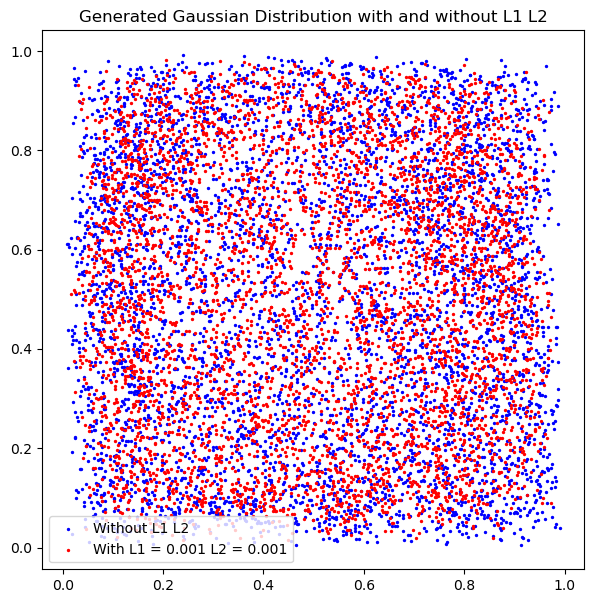

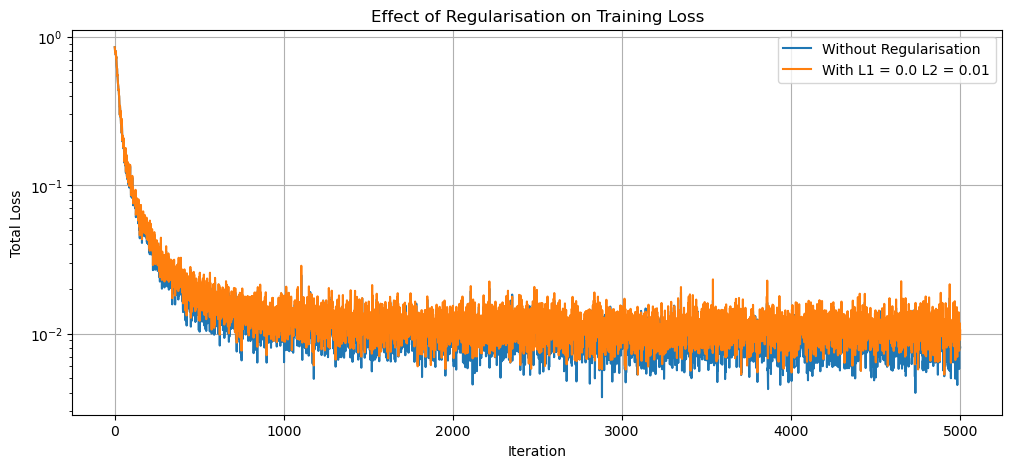

Iteration    0 | MMD Loss: 0.851574 | Total Loss: 4.390993
Iteration  500 | MMD Loss: 0.079444 | Total Loss: 1.646283
Iteration 1000 | MMD Loss: 0.070081 | Total Loss: 0.811504
Iteration 1500 | MMD Loss: 0.056076 | Total Loss: 0.626868
Iteration 2000 | MMD Loss: 0.062922 | Total Loss: 0.536702
Iteration 2500 | MMD Loss: 0.043964 | Total Loss: 0.447606
Iteration 3000 | MMD Loss: 0.047167 | Total Loss: 0.397633
Iteration 3500 | MMD Loss: 0.045463 | Total Loss: 0.357317
Iteration 4000 | MMD Loss: 0.037056 | Total Loss: 0.324231
Iteration 4500 | MMD Loss: 0.033992 | Total Loss: 0.304631


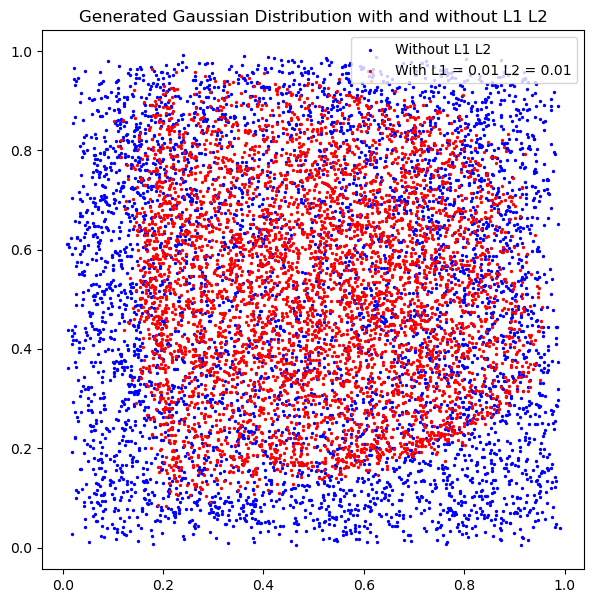

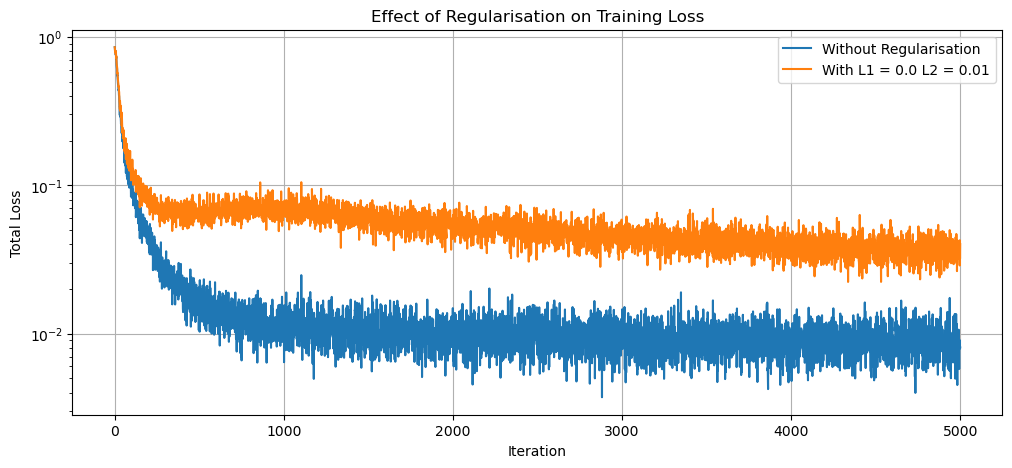

In [9]:
for lambda_l in [0.001, 0.01]:
    torch.manual_seed(42)
    f1L1L2 = Generatorf1()
    loss_history = []
    mmd_history = []
    learning_rate = 0.01
    num_iterations = 5000
    batch_size = 256

    for iteration in range(num_iterations):
    
        # Generate a minibatch from N(0, I)
        z = torch.randn(batch_size, 2)
    
        # Generate empirical samples from U([0, 1]^2)
        target = torch.rand(batch_size, 2)
    
        # Forward pass
        generated = f1L1L2(z)
    
        # Compare generated and target distributions
        mmd = mmd_loss(generated, target)
        
        l1 = l1_penalty(f1L1L2)
        l2 = l2_penalty(f1L1L2)
        
        loss = mmd + lambda_l * l1 + lambda_l * l2
    
        # Remove gradients from the previous iteration
        f1L1L2.zero_grad()
    
        # Calculate gradients using backpropagation
        loss.backward()
    
        # Explicit SGD update:
        # parameter_new = parameter_old - learning_rate * gradient
        with torch.no_grad():
            for parameter in f1L1L2.parameters():
                parameter -= learning_rate * parameter.grad
    
        # Store the loss
        loss_history.append(loss.item())
        mmd_history.append(mmd.item())
    
    
        if iteration % 500 == 0:
            print(
                f"Iteration {iteration:4d} | "
                f"MMD Loss: {mmd.item():.6f} | "
                f"Total Loss: {loss.item():.6f}"
            )
    with torch.no_grad():
        z_test = torch.randn(5000, 2)
        generated_test = f1(z_test)
        generated_test_withL1L2 = f1L1L2(z_test)
    
    plt.figure(figsize=(7, 7))
    
    plt.scatter(
        generated_test[:, 0],
        generated_test[:, 1],
        s=2,
        color="blue",
        label="Without L1 L2"
    )
    plt.scatter(
        generated_test_withL1L2[:, 0],
        generated_test_withL1L2[:, 1],
        s=2,
        color="red",
        label="With L1 = " + str(lambda_l) +
              " L2 = " + str(lambda_l)
    )
    
    plt.title("Generated Gaussian Distribution with and without L1 L2")
    plt.legend()        
    plt.savefig(
        "genf1L1" + str(lambda_l) +
        "L2" + str(lambda_l) + ".png",
        bbox_inches="tight"
    )
    plt.show()
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(loss_history_f1, label="Without Regularisation")
    plt.plot(mmd_history, label="With L1 = " + str(lambda_l1) +" L2 = " + str(lambda_l2))
    
    plt.xlabel("Iteration")
    plt.ylabel("Total Loss")
    plt.title("Effect of Regularisation on Training Loss")
    plt.legend()
    plt.grid()
    plt.yscale("log")
    plt.savefig(
        "lossgenf1L1" + str(lambda_l) +
        "L2" + str(lambda_l) + ".png",
        bbox_inches="tight"
    )
    plt.show()


number of features = 4
Iteration    0 | Loss: 0.383020
Iteration  500 | Loss: 0.020872
Iteration 1000 | Loss: 0.019922
Iteration 1500 | Loss: 0.017218
Iteration 2000 | Loss: 0.015841
Iteration 2500 | Loss: 0.013807
Iteration 3000 | Loss: 0.014868
Iteration 3500 | Loss: 0.013703
Iteration 4000 | Loss: 0.014606
Iteration 4500 | Loss: 0.014552


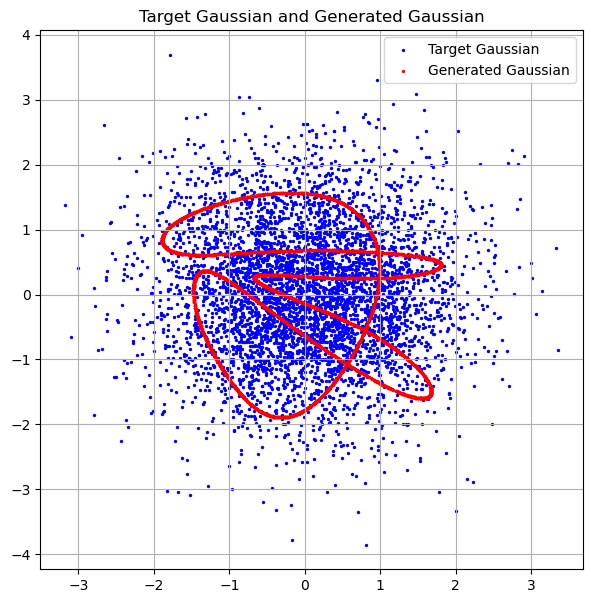

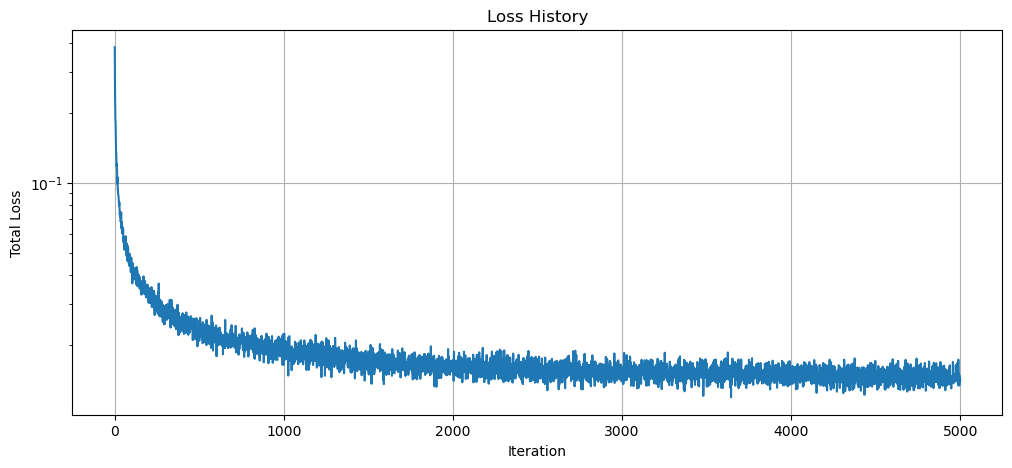

number of features = 8
Iteration    0 | Loss: 0.286170
Iteration  500 | Loss: 0.014734
Iteration 1000 | Loss: 0.010674
Iteration 1500 | Loss: 0.009181
Iteration 2000 | Loss: 0.008281
Iteration 2500 | Loss: 0.008643
Iteration 3000 | Loss: 0.007749
Iteration 3500 | Loss: 0.008198
Iteration 4000 | Loss: 0.008028
Iteration 4500 | Loss: 0.007766


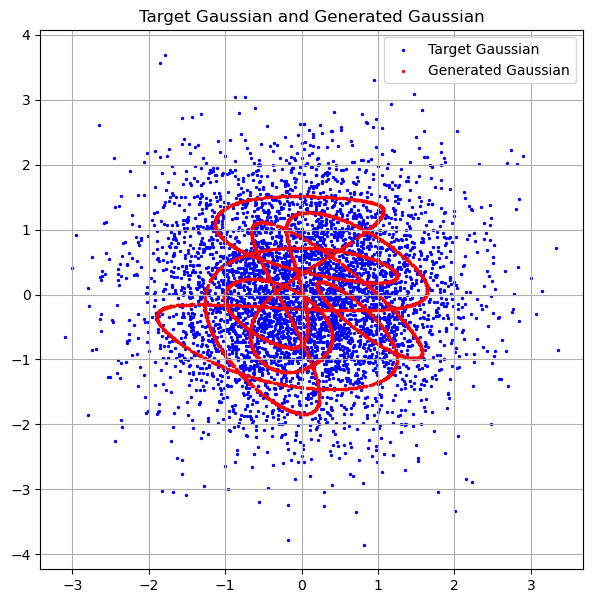

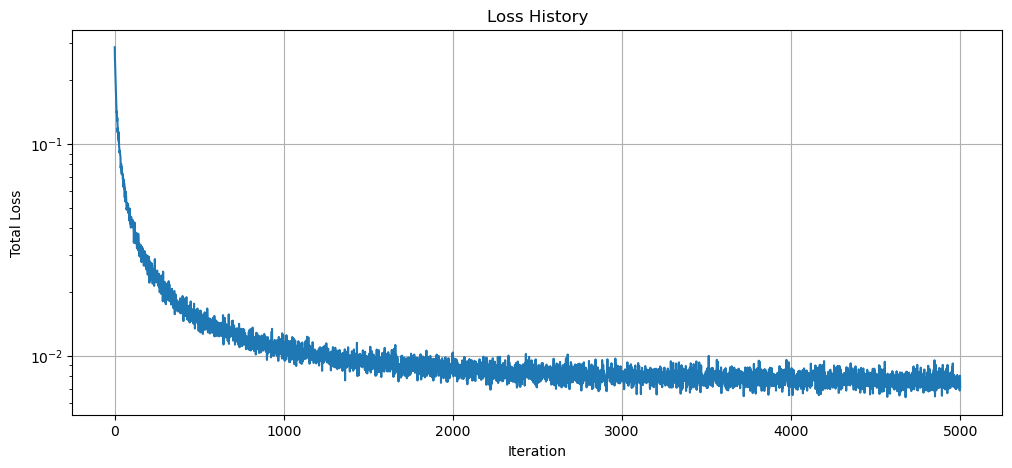

number of features = 16
Iteration    0 | Loss: 0.315424
Iteration  500 | Loss: 0.014175
Iteration 1000 | Loss: 0.007543
Iteration 1500 | Loss: 0.007186
Iteration 2000 | Loss: 0.006500
Iteration 2500 | Loss: 0.005969
Iteration 3000 | Loss: 0.006679
Iteration 3500 | Loss: 0.005735
Iteration 4000 | Loss: 0.005391
Iteration 4500 | Loss: 0.005365


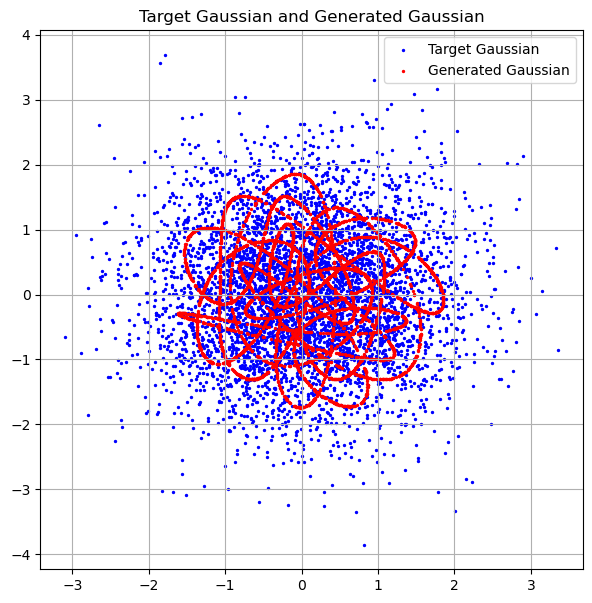

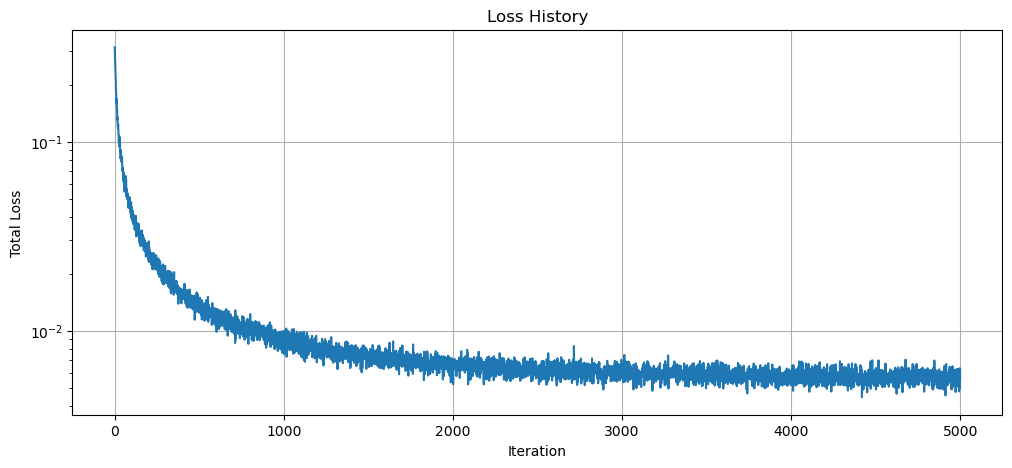

In [10]:
for num_feature in [4, 8, 16]:
    print("number of features = "+str(num_feature))
    
    torch.manual_seed(42)
    f3 = Generatorf3(num_feature)
    
    learning_rate = 0.01
    num_iterations = 5000
    batch_size = 512
    loss_history_f3 = []
    
    for iteration in range(num_iterations):
        # Input: 1D Uniform distribution U(0,1)
        y = torch.rand(batch_size, 1)
    
        # Target: 2D Gaussian distribution N(0,I)
        target = torch.randn(batch_size, 2)
    
        # Generate 2D samples
        generated = f3(y)
    
        # MMD loss
        loss = mmd_loss(generated, target)
    
        # Remove gradients from the previous iteration
        f3.zero_grad()
    
        # Calculate gradients
        loss.backward()
    
        # Update network parameters
        with torch.no_grad():
            for parameter in f3.parameters():
                parameter -= learning_rate * parameter.grad
    
        # Store loss
        loss_history_f3.append(loss.item())
    
        if iteration % 500 == 0:
            print(
                f"Iteration {iteration:4d} | "
                f"Loss: {loss.item():.6f}"
            )
    with torch.no_grad():
    
        y_test = torch.rand(5000, 1)
        generated_test = f3(y_test)
    
        target_test = torch.randn(5000, 2)
    
    plt.figure(figsize=(7, 7))
    
    plt.scatter(
        target_test[:, 0],
        target_test[:, 1],
        s=2,
        color="blue",
        label="Target Gaussian"
    )
    
    plt.scatter(
        generated_test[:, 0],
        generated_test[:, 1],
        s=2,
        color="red",
        label="Generated Gaussian"
    )
    
    plt.title("Target Gaussian and Generated Gaussian")
    plt.legend()
    plt.grid()
    
    plt.savefig("targetVSgenf3"+str(num_feature)+"features")
    plt.show()
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(loss_history_f3,)
    
    plt.xlabel("Iteration")
    plt.ylabel("Total Loss")
    plt.title("Loss History")
    plt.grid()
    plt.yscale("log")
    plt.savefig("lossgenf3"+str(num_feature)+"features")
    plt.show()